# Introducción
## **EuroSAT**
- **Objetivo de la Red Neuronal**: Clasificar imágenes satelitales en 10 categorías.
- **Objetivo**: Implementar una arquitectura de deep learning (transfer learning + fine tune) en Keras/TensorFlow, evaluar y mejorar mediante técnicas de regularización y ajuste de hiperparámetros


# Datos: descarga y EDA

## Referencia del Dataset

**EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification**

- **Autores:** Helber, P., Bischke, B., Dengel, A., & Borth, D.
- **Año:** 2019
- **Publicación:** IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, 12(7), 2217-2226
- **Enlace:** [TensorFlow Datasets - EuroSAT](https://www.tensorflow.org/datasets/catalog/eurosat)
- **DOI:** 10.1109/JSTARS.2019.2918242

El dataset EuroSAT está disponible públicamente y fue creado para servir como benchmark en tareas de clasificación de uso de suelo mediante imágenes satelitales.

In [11]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import itertools

## Descripción del Dataset

**Características:**
- **Tipo:** Imágenes satelitales RGB
- **Clases:** 10 categorías de tipos de suelo
- **Tamaño total:** 27,000 imágenes aprox.
- **Resolución:** Imagenes de 64 x 64 pixeles

**Categorías:**
1. AnnualCrop
2. Forest
3. HerbaceousVegetation
4. Highway
5. Industrial
6. Pasture
7. PermanentCrop
8. Residential
9. River
10. SeaLake

Este dataset es ideal para el problema ya que representa un caso de uso real en monitoreo ambiental y no es un "toy dataset".

In [ ]:
# Nota: esto descargará el dataset la primera vez.
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    "eurosat/rgb",   # RGB version
    split=["train[:80%]", "train[80%:90%]", "train[90%:]"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

tfds.core.DatasetInfo(
    name='eurosat',
    full_name='eurosat/rgb/2.0.0',
    description="""
    EuroSAT dataset is based on Sentinel-2 satellite images covering 13 spectral
    bands and consisting of 10 classes with 27000 labeled and
    geo-referenced samples.
    
    Two datasets are offered:
    - rgb: Contains only the optical R, G, B frequency bands encoded as JPEG image.
    - all: Contains all 13 bands in the original value range (float32).
    
    URL: https://github.com/phelber/eurosat
    """,
    config_description="""
    Sentinel-2 RGB channels
    """,
    homepage='https://github.com/phelber/eurosat',
    data_dir='/Users/jose.tahuilan/tensorflow_datasets/eurosat/rgb/2.0.0',
    file_format=tfrecord,
    download_size=89.91 MiB,
    dataset_size=89.50 MiB,
    features=FeaturesDict({
        'filename': Text(shape=(), dtype=string),
        'image': Image(shape=(64, 64, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),

## Resumen Estadístico del Dataset

El dataset EuroSAT contiene un total de **27,000 imágenes** de imágenes satelitales RGB, distribuidas de manera balanceada entre las 10 clases de uso de suelo.

**Características del dataset:**
- **Balance de clases**: El dataset está balanceado, con aproximadamente 2,700 imágenes por clase en el conjunto completo
- **Resolución original**: 64x64 píxeles
- **Formato**: RGB (3 canales de color)
- **Distribución**: Cada clase tiene aproximadamente el mismo número de instancias, lo que facilita el entrenamiento de modelos de clasificación

Este balance en la distribución de clases es ideal para entrenar modelos de clasificación, ya que evita problemas de sesgo hacia clases mayoritarias.


In [ ]:
print(ds_info)
NUM_CLASSES = ds_info.features['label'].num_classes
CLASS_NAMES = ds_info.features['label'].names

print("Classes:")
for clas in CLASS_NAMES:
    print(clas)

Contando muestras por clase en todos los conjuntos...


2025-11-25 17:07:03.450389: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


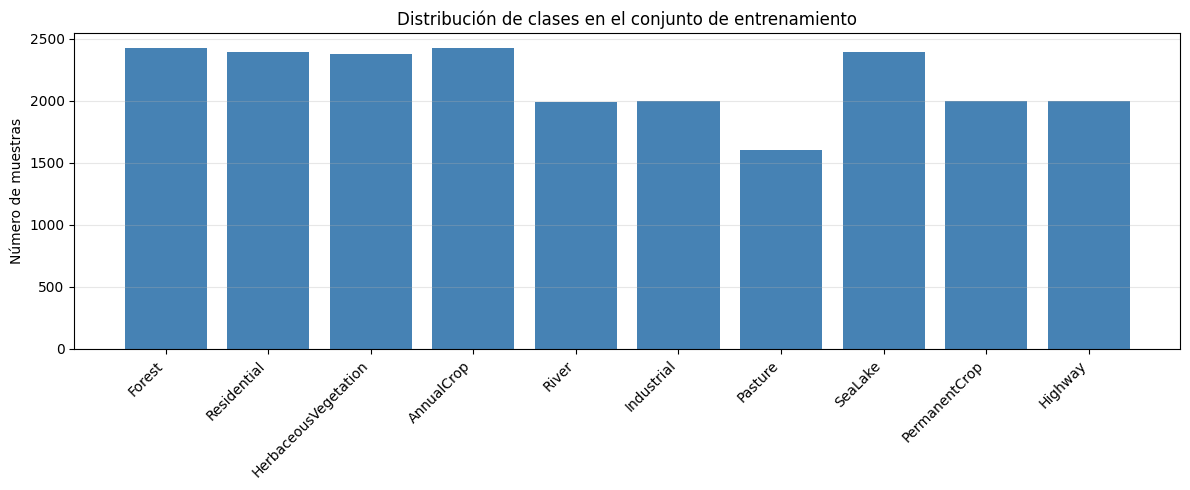


RESUMEN DEL DATASET EUROSAT

Total de imágenes en el dataset: 27,000

División de datos:
  - Entrenamiento: 21,600 imágenes (80.0%)
  - Validación:    2,700 imágenes (10.0%)
  - Prueba:        2,700 imágenes (10.0%)

Distribución por clase en el conjunto de ENTRENAMIENTO:
  AnnualCrop               :  2427 muestras (11.24%)
  Forest                   :  2425 muestras (11.23%)
  HerbaceousVegetation     :  2379 muestras (11.01%)
  Highway                  :  1996 muestras ( 9.24%)
  Industrial               :  1999 muestras ( 9.25%)
  Pasture                  :  1603 muestras ( 7.42%)
  PermanentCrop            :  1996 muestras ( 9.24%)
  Residential              :  2392 muestras (11.07%)
  River                    :  1989 muestras ( 9.21%)
  SeaLake                  :  2394 muestras (11.08%)


In [13]:
# Contar muestras por clase en cada conjunto
def count_samples(dataset, dataset_name):
    class_counts = {}
    total = 0
    for image, label in dataset:
        label_int = int(label.numpy())
        class_name = CLASS_NAMES[label_int]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
        total += 1
    return class_counts, total

print("Contando muestras por clase en todos los conjuntos...")
train_counts, train_total = count_samples(ds_train, "entrenamiento")
val_counts, val_total = count_samples(ds_val, "validación")
test_counts, test_total = count_samples(ds_test, "prueba")

total_images = train_total + val_total + test_total

# Visualizar distribución del conjunto de entrenamiento
plt.figure(figsize=(12, 5))
classes = list(train_counts.keys())
counts = list(train_counts.values())
plt.bar(classes, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Número de muestras')
plt.title('Distribución de clases en el conjunto de entrenamiento')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimir resumen completo
print(f"\n{'='*70}")
print(f"RESUMEN DEL DATASET EUROSAT")
print(f"{'='*70}")
print(f"\nTotal de imágenes en el dataset: {total_images:,}")
print(f"\nDivisión de datos:")
print(f"  - Entrenamiento: {train_total:,} imágenes ({train_total/total_images*100:.1f}%)")
print(f"  - Validación:    {val_total:,} imágenes ({val_total/total_images*100:.1f}%)")
print(f"  - Prueba:        {test_total:,} imágenes ({test_total/total_images*100:.1f}%)")
print(f"\n{'='*70}")
print(f"Distribución por clase en el conjunto de ENTRENAMIENTO:")
print(f"{'='*70}")
for cls in sorted(train_counts.keys()):
    cnt = train_counts[cls]
    percentage = (cnt / train_total) * 100
    print(f"  {cls:25s}: {cnt:5d} muestras ({percentage:5.2f}%)")

Ejemplos de imágenes del dataset:


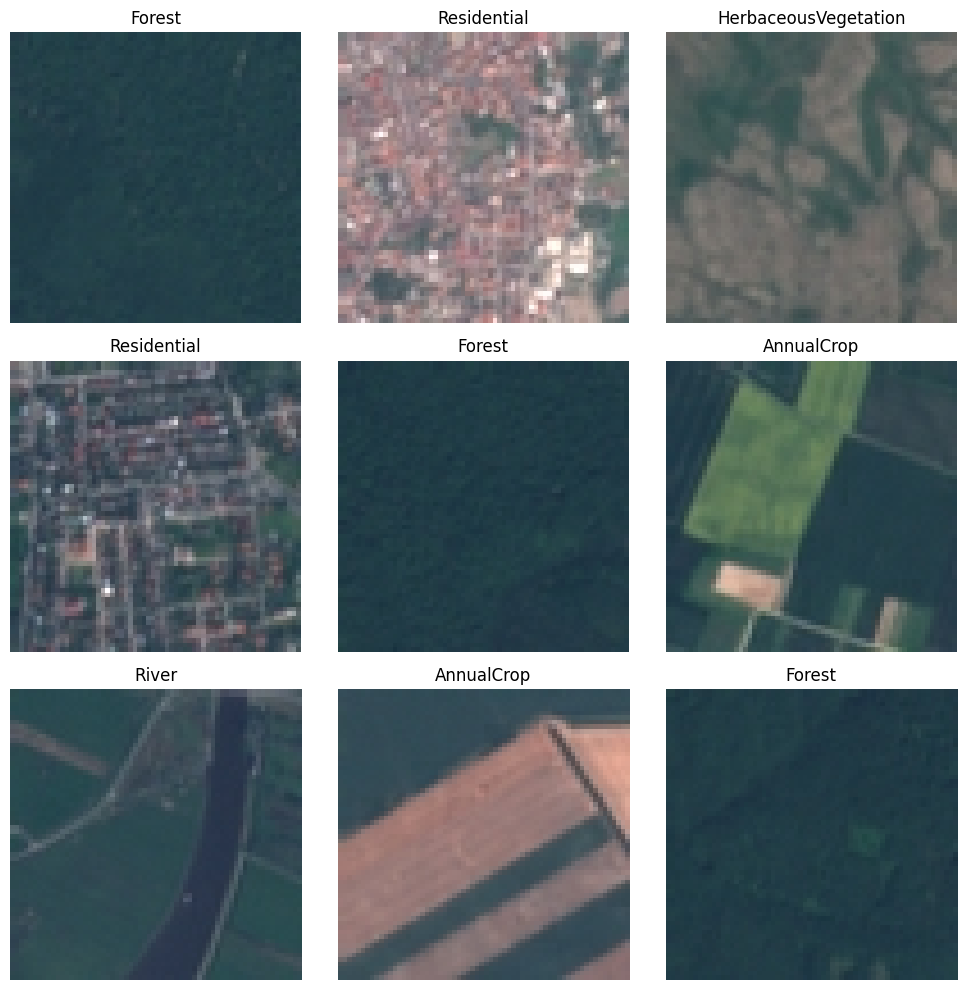

In [14]:
def show_examples(dataset, class_names, n=9):
    plt.figure(figsize=(10, 10))
    for i, (image, label) in enumerate(dataset.take(n)):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(tf.cast(image, tf.uint8))
        plt.title(class_names[int(label)])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Ejemplos de imágenes del dataset:")
show_examples(ds_train, CLASS_NAMES, n=9)


## Separación de datos

l dataset se divide en tres conjuntos:

- **Conjunto de Entrenamiento (80%)**: Aproximadamente 21,600 imágenes utilizadas para entrenar el modelo
- **Conjunto de Validación (10%)**: Aproximadamente 2,700 imágenes utilizadas para ajustar hiperparámetros y monitorear el entrenamiento
- **Conjunto de Prueba (10%)**: Aproximadamente 2,700 imágenes utilizadas para la evaluación final del modelo



# Preprocesamiento y pipeline

In [ ]:
BATCH_SIZE = 64
IMG_SIZE = (128, 128)
AUTOTUNE = tf.data.AUTOTUNE

from tensorflow.keras.applications.efficientnet import preprocess_input

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, label

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

In [ ]:
ds_train = ds_train.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.shuffle(2048).batch(BATCH_SIZE).prefetch(AUTOTUNE)

ds_val = ds_val.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Desarrollo del modelo: transferencia + cabeza custom

In [ ]:
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.optimizers import AdamW

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3),
    pooling=None
)
base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
earlystop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
chk = callbacks.ModelCheckpoint("models/model_best_initial.keras", save_best_only=True, monitor='val_loss')

In [ ]:
EPOCHS = 10
history = model.fit(
    ds_train,
    epochs=EPOCHS,
    validation_data=ds_val,
    callbacks=[earlystop, reduce_lr, chk],
    verbose=1
)

Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 115s 329ms/step - accuracy: 0.8304 - loss: 0.8732 - val_accuracy: 0.9241 - val_loss: 0.5076 - learning_rate: 0.0010
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 112s 330ms/step - accuracy: 0.8838 - loss: 0.5933 - val_accuracy: 0.9296 - val_loss: 0.4215 - learning_rate: 0.0010
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 125s 368ms/step - accuracy: 0.8814 - loss: 0.5366 - val_accuracy: 0.9230 - val_loss: 0.3882 - learning_rate: 0.0010
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 123s 362ms/step - accuracy: 0.8881 - loss: 0.5027 - val_accuracy: 0.9281 - val_loss: 0.3675 - learning_rate: 0.0010
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 111s 328ms/step - accuracy: 0.8885 - loss: 0.4835 - val_accuracy: 0.9322 - val_loss: 0.3570 - learning_rate: 0.0010
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 123s 365ms/step - accuracy: 0.8896 - loss: 0.4842 - val_accuracy: 0.9311 - val_loss: 0.3558 - learning_rate: 0.0010
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 123s 365ms/step - accura

# Ajuste del modelo

## Fine-tuning

Después del entrenamiento inicial con la base congelada, se realizó un proceso de **fine-tuning** para mejorar el rendimiento del modelo. Esta es una técnica estándar en transfer learning que permite adaptar el modelo pre-entrenado a nuestro dominio específico.

### Cambios realizados:

1. **Descongelamiento selectivo de capas:**
   - Se descongelaron las últimas 30 capas del modelo base EfficientNetB0.
   - Las capas iniciales permanecen congeladas.
   - Las capas finales se adaptan a las características específicas de imágenes satelitales

2. **Ajuste de hiperparámetros:**
   - **Learning rate reducido:** De 1e-3 a 1e-5
   - **Weight decay aumentado:** De 1e-4 a 1e-5

3. **Callbacks mantenidos:**
   - EarlyStopping: Previene sobreentrenamiento
   - ReduceLROnPlateau: Reduce el learning rate automáticamente si no hay mejora
   - ModelCheckpoint: Guarda el mejor modelo según val_loss

### Resultados del ajuste:

**Antes del fine-tuning (base congelada):**
- Test accuracy: 93.44%
- Test loss: 0.3549

**Después del fine-tuning:**
- Test accuracy: 94.07%
- Test loss: 0.3492

**Mejora obtenida:**
- +0.63% en accuracy
- Reducción en loss de 0.0057

# Evaluación inicial

In [ ]:
test_loss, test_acc = model.evaluate(ds_test)
print(f"Test accuracy (base frozen): {test_acc:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 307s 7s/step - accuracy: 0.9344 - loss: 0.3549
Test accuracy (base frozen): 0.9344


# Resultados

## Evaluación del modelo final

El modelo final fue evaluado en el conjunto de prueba (test set) que no fue utilizado durante el entrenamiento ni el ajuste de hiperparámetros. A continuación se presentan los resultados detallados.


In [ ]:
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

chk_ft = callbacks.ModelCheckpoint("models/model_best_finetune.keras", save_best_only=True, monitor='val_loss')
earlystop_ft = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

EPOCHS_FT = 10
history_ft = model.fit(
    ds_train,
    epochs=EPOCHS_FT,
    validation_data=ds_val,
    callbacks=[earlystop_ft, reduce_lr, chk_ft],
    verbose=1
)

Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 139s 395ms/step - accuracy: 0.7928 - loss: 0.7980 - val_accuracy: 0.9015 - val_loss: 0.4497 - learning_rate: 1.0000e-05
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 153s 452ms/step - accuracy: 0.8450 - loss: 0.6161 - val_accuracy: 0.9148 - val_loss: 0.4064 - learning_rate: 1.0000e-05
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 145s 428ms/step - accuracy: 0.8710 - loss: 0.5552 - val_accuracy: 0.9241 - val_loss: 0.3786 - learning_rate: 1.0000e-05
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 145s 428ms/step - accuracy: 0.8770 - loss: 0.5238 - val_accuracy: 0.9267 - val_loss: 0.3695 - learning_rate: 5.0000e-06
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 137s 405ms/step - accuracy: 0.8828 - loss: 0.5093 - val_accuracy: 0.9296 - val_loss: 0.3613 - learning_rate: 5.0000e-06
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 126s 371ms/step - accuracy: 0.8849 - loss: 0.4971 - val_accuracy: 0.9333 - val_loss: 0.3543 - learning_rate: 5.0000e-06
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
final_loss, final_acc = model.evaluate(ds_test)
print(f"Final test accuracy (fine-tuned): {final_acc:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - accuracy: 0.9407 - loss: 0.3492
Final test accuracy (fine-tuned): 0.9407


2025-11-10 17:01:06.060596: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


                      precision    recall  f1-score   support

          AnnualCrop       0.88      0.97      0.92       276
              Forest       0.94      0.99      0.96       286
HerbaceousVegetation       0.94      0.94      0.94       317
             Highway       0.89      0.91      0.90       252
          Industrial       0.97      0.96      0.96       257
             Pasture       0.96      0.85      0.90       191
       PermanentCrop       0.94      0.85      0.89       267
         Residential       0.97      0.98      0.98       310
               River       0.92      0.93      0.93       245
             SeaLake       1.00      0.97      0.98       299

            accuracy                           0.94      2700
           macro avg       0.94      0.94      0.94      2700
        weighted avg       0.94      0.94      0.94      2700



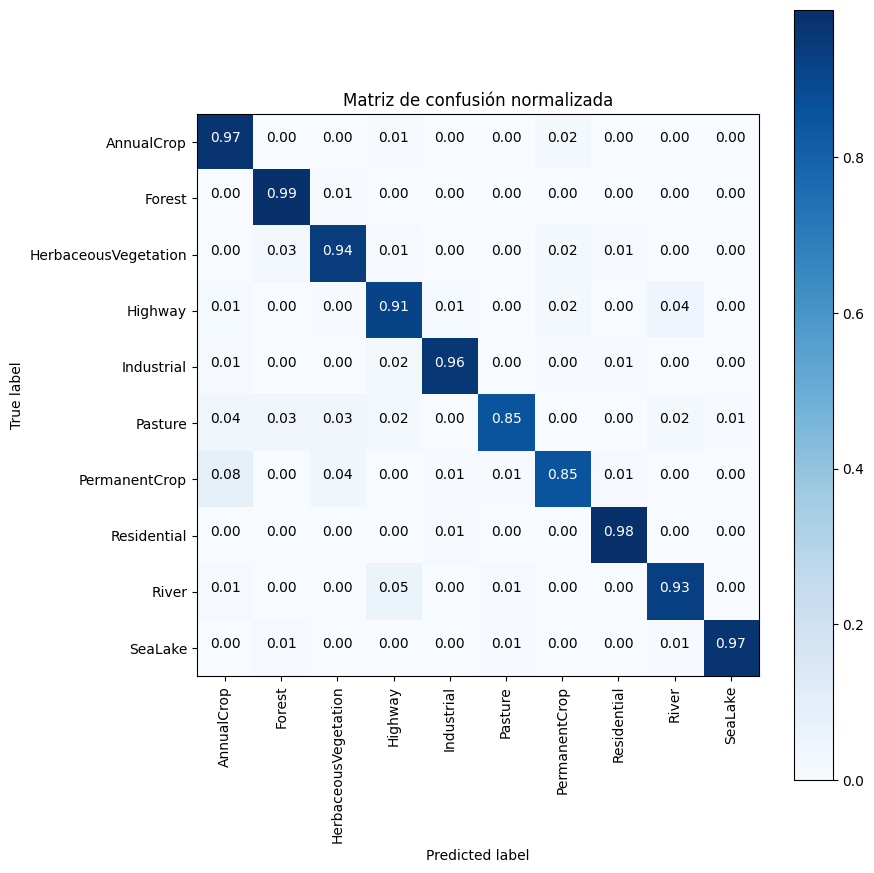

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

y_true, y_pred = [], []
for images, labels in ds_test:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(9,9))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]:.0f}" if not normalize else f"{cm[i, j]:.2f}",
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

plot_confusion_matrix(cm, CLASS_NAMES, normalize=True, title="Matriz de confusión normalizada")

In [ ]:
os.makedirs("models", exist_ok=True)
model.save("models/model_final.keras", include_optimizer=False)
print("Modelo final guardado en models/model_final.keras")

Modelo final guardado en models/model_final.keras


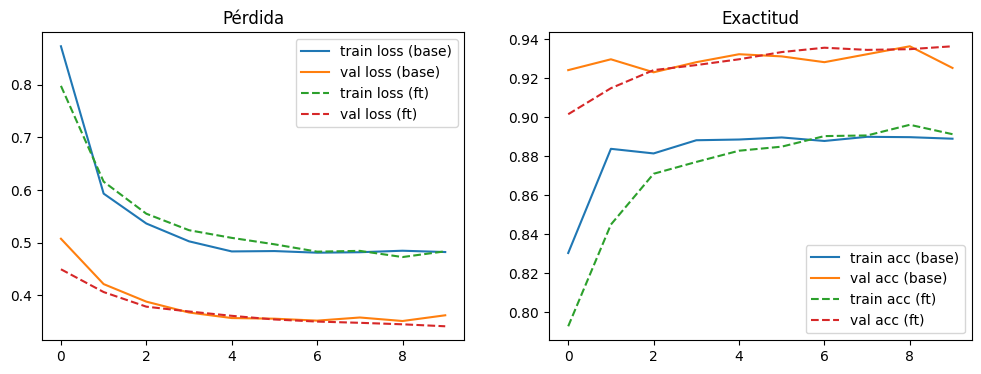

In [ ]:
def plot_history(h1, h2=None):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(h1.history['loss'], label='train loss (base)')
    plt.plot(h1.history['val_loss'], label='val loss (base)')
    if h2:
        plt.plot(h2.history['loss'], '--', label='train loss (ft)')
        plt.plot(h2.history['val_loss'], '--', label='val loss (ft)')
    plt.legend(); plt.title('Pérdida')

    plt.subplot(1,2,2)
    plt.plot(h1.history['accuracy'], label='train acc (base)')
    plt.plot(h1.history['val_accuracy'], label='val acc (base)')
    if h2:
        plt.plot(h2.history['accuracy'], '--', label='train acc (ft)')
        plt.plot(h2.history['val_accuracy'], '--', label='val acc (ft)')
    plt.legend(); plt.title('Exactitud')

    plt.show()

plot_history(history, history_ft)

## Análisis de resultados

El modelo alcanzó una **accuracy del 94.07%** en el conjunto de prueba, lo cual es un excelente resultado para un problema de clasificación de 10 clases.

### Análisis por clase

Observando el reporte de clasificación y la matriz de confusión:

**Clases con mejor rendimiento:**
- **SeaLake:** Recall=0.97, F1=0.98
  - Excelente rendimiento, probablemente debido a características a que se nota el agua de color azul.
- **Residential:** Recall=0.98, F1=0.98
  - Patrones urbanos claramente identificables
- **Forest:** Precision=0.94, Recall=0.99, F1=0.96
  - Texturas verdes características muy bien capturadas

**Clases con menor rendimiento (aunque aún bueno):**
- **Pasture (Pastizales):** Recall=0.85, F1=0.90
  - Puede confundirse con HerbaceousVegetation o AnnualCrop
- **PermanentCrop (Cultivos permanentes):** Recall=0.85, F1=0.89
  - Similar a Pasture, puede tener confusión con otras clases de vegetación

**Observaciones:**
- El modelo muestra confusión principalmente entre clases de vegetación similares (Pasture, PermanentCrop, HerbaceousVegetation, AnnualCrop)
- Las clases con características más distintivas como el agua o edificios tienen mejor rendimiento, seguramente por el color caracteristico.


**Resultado**
- De 93.44% a 94.07% en Accuracy, despues de fine-tunning.
- De 0.3549 a 0.3492 en Perdidad, despues de fine-tunning.


El fine-tuning logró una mejora modesta pero consistente, lo cual es esperado ya que el modelo inicial ya tenía un buen rendimiento. La mejora es significativa en términos prácticos para aplicaciones de monitoreo de uso de suelo.


# Aplicación

## Función para probar el modelo con datos nuevos

A continuación se presenta una función que permite utilizar el modelo entrenado para realizar predicciones sobre nuevas imágenes satelitales. Esta función puede ser utilizada desde la consola o integrada en una interfaz gráfica.


In [ ]:
from PIL import Image

def predict_from_path(model_path, img_path, class_names=CLASS_NAMES, show_image=True):
    """
    Realiza una predicción sobre una imagen satelital nueva.

    Parámetros:
    -----------
    model_path : str
        Ruta al modelo guardado (.keras)
    img_path : str
        Ruta a la imagen a clasificar
    class_names : list
        Lista de nombres de clases (por defecto CLASS_NAMES)
    show_image : bool
        Si True, muestra la imagen junto con la predicción

    Retorna:
    --------
    dict : Diccionario con la clase predicha, probabilidad y todas las probabilidades
    """
    # Cargar modelo
    model = tf.keras.models.load_model(model_path)

    # Cargar y preprocesar imagen
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    img_array = np.array(img)
    img_array_preprocessed = preprocess_input(img_array)

    # Realizar predicción
    pred = model.predict(np.expand_dims(img_array_preprocessed, axis=0), verbose=0)
    idx = np.argmax(pred, axis=1)[0]
    confidence = pred[0][idx] * 100

    # Mostrar imagen si se solicita
    if show_image:
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f'Imagen original')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.barh(range(len(class_names)), pred[0] * 100)
        plt.yticks(range(len(class_names)), class_names)
        plt.xlabel('Probabilidad (%)')
        plt.title(f'Predicción: {class_names[idx]} ({confidence:.2f}%)')
        plt.tight_layout()
        plt.show()

    # Imprimir resultado
    print(f"\n{'='*50}")
    print(f"Predicción: {class_names[idx]}")
    print(f"Confianza: {confidence:.2f}%")
    print(f"{'='*50}")
    print("\nProbabilidades para todas las clases:")
    sorted_indices = np.argsort(pred[0])[::-1]
    for i in sorted_indices:
        print(f"  {class_names[i]:25s}: {pred[0][i]*100:5.2f}%")

    return {
        'predicted_class': class_names[idx],
        'confidence': confidence,
        'all_probabilities': {class_names[i]: float(pred[0][i]) for i in range(len(class_names))}
    }

# Ejemplo de uso (descomentar y proporcionar ruta a una imagen):
# resultado = predict_from_path("models/model_final.keras", "/ruta/a/una_imagen.jpg")

# Conclusiones

El modelo de deep learning implementado utilizando transfer learning con EfficientNetB0 y fine-tuning logró un **accuracy del 94.07%** en el conjunto de prueba, demostrando ser efectivo para la clasificación de imágenes satelitales en 10 categorías de uso de suelo. Se lograron las siguientes cosas:

1. **Arquitectura efectiva:** El uso de EfficientNetB0 como modelo base proporcionó una excelente base de características pre-entrenadas que se adaptaron bien al dominio de imágenes satelitales.

2. **Técnicas de regularización exitosas:**
   - Data augmentation ayudó a generalizar mejor
   - Dropout (0.4) y regularización L2 previno sobreajuste
   - Early stopping y reducción de learning rate optimizaron el entrenamiento

3. **Fine-tuning efectivo:** El proceso de descongelamiento selectivo de capas mejoró el rendimiento en 0.63%, adaptando el modelo al dominio específico sin perder generalización.

### Áreas de mejora identificadas:

1. **Confusión entre clases de vegetación:** Las clases Pasture, PermanentCrop, HerbaceousVegetation y AnnualCrop muestran cierta confusión, lo que podriamos solucionar al aumentar el tamaño del dataset con más ejemplos de estas clases.

2. **Tamaño de imagen:**: Las imágenes se redimensionaron a 128x128, perdiendo resolución original, lo solucionariamos probar con imágenes de mayor resolución (224x224 o 256x256).


### Reflexiones finales:

Este proyecto demostró la efectividad del transfer learning para problemas de visión computacional en dominios específicos. El uso de modelos pre-entrenados permite lograr excelentes resultados con menos datos y tiempo de entrenamiento que entrenar desde cero. El proceso de fine-tuning fue crucial para adaptar el modelo al dominio de imágenes satelitales, mejorando el rendimiento de manera consistente.

El modelo final es robusto y puede ser desplegado en aplicaciones reales, aunque hay espacio para mejoras adicionales mediante las técnicas mencionadas anteriormente.
